# NFL Route Tracker — Animated Trajectory Visualization & Synthetic Route Generation 

---
## Important Packages

In [1]:
# 1. Core utilities
import sys
import json
import numpy as np
from pathlib import Path
from typing import Dict, List, Tuple, Optional

# 2. Matplotlib 
import matplotlib
import matplotlib.pyplot as plt

# 3. Plotly 
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display

# 4. Add project path 
PROJECT_ROOT = Path("..")
sys.path.insert(0, str(PROJECT_ROOT / "src"))

# 5. NFL imports LAST
from nfl_route_tracker.skill_players import (TrajectoryDataLoader, classify_offense_defense, SkillPositionFilter,
)
from nfl_route_tracker.skill_players.synthetic_route_generator import (SyntheticRouteGenerator, RouteParameters, RouteType,)
from nfl_route_tracker.core.video_loader import VideoLoader

✅ Matplotlib imported
✅ Plotly imported
✅ Project path added
Importing nfl_route_tracker...
✅ NFL Route Tracker fully imported!


---
## Choose video here

In [23]:
# subfolder video name
SUBFOLDER_NAME = "vid109"          # e.g. "vid_demo4"

VIZ_OUTPUT     = PROJECT_ROOT / "data" / "viz_output"
SUBDIR         = VIZ_OUTPUT / SUBFOLDER_NAME
SUBDIR2 = PROJECT_ROOT / "data" / "video_test" 

# Auto-locate JSON and MP4
json_files = list(SUBDIR.glob("*_trajectories.json"))
# mp4_files  = list(SUBDIR2.glob("*.mp4"))
mp4_files  = list(SUBDIR2.glob("vid109.mp4"))

assert json_files, f"No trajectory JSON found in {SUBDIR}"
#assert mp4_files,  f"No .mp4 found in {SUBDIR} — needed for video dimensions"

JSON_PATH = json_files[0]
MP4_PATH  = mp4_files[0]

print(f"JSON : {JSON_PATH.name}")
print(f"Video: {MP4_PATH.name}")

# pull true video dimensions from the mp4
with VideoLoader(MP4_PATH) as vl:
    VIDEO_W = float(vl.metadata.width)
    VIDEO_H = float(vl.metadata.height)
    TOTAL_FRAMES = vl.metadata.total_frames
    FPS = vl.metadata.fps
    TIME = vl.metadata.duration_seconds

print(f"Dimensions   : {int(VIDEO_W)} x {int(VIDEO_H)}")
print(f"Total frames : {TOTAL_FRAMES}")
print(FPS)
print(TIME)

JSON : vid109_trajectories.json
Video: vid109.mp4
Video released successfully
Dimensions   : 1920 x 988
Total frames : 199
57.07456978967495
3.486666666666667


---
## Load & classify trajectories

In [3]:
# Load raw trajectories
loader = TrajectoryDataLoader()
video_traj = loader.load_trajectory_json(JSON_PATH)
trajectories = video_traj.trajectories
print(f"Loaded {len(trajectories)} trajectories")

# classify offense / defense
trajectories, los = classify_offense_defense(trajectories, method = "minimal_movement", video_width = VIDEO_W, video_height = VIDEO_H,)
print(f"Offense: {sum(1 for t in trajectories if t.team == 'offense')}  "
      f"Defense: {sum(1 for t in trajectories if t.team == 'defense')}")

# classify skill positions
skill_filter = SkillPositionFilter(los)
skill_positions, non_skill = skill_filter.filter_skill_positions(trajectories)
print(f"Skill: {len(skill_positions)}  Non-skill: {len(non_skill)}")

# Build a lookup: track_id → ParsedTrajectory
traj_by_id = {t.track_id: t for t in trajectories}

Loaded 24 trajectories
Offense: 13  Defense: 11
Skill: 4  Non-skill: 9


---
## Helper — build per-frame detection lookup

In [4]:
def build_frame_lookup(trajectories) -> Dict[int, List[dict]]:
    lookup: Dict[int, List[dict]] = {}
    for traj in trajectories:
        for det in traj.detections:
            cx, cy = det.center
            entry = dict(track_id = traj.track_id,
                         cx = cx, cy = cy,
                         team  = traj.team or "unknown",
                         position = traj.position or "UNKNOWN",
                         is_skill = traj.is_skill_position,)
            lookup.setdefault(det.frame_id, []).append(entry)
    return lookup

# sort frame indices 
def get_sorted_frames(trajectories) -> List[int]:
    frames = set()
    for traj in trajectories:
        for det in traj.detections:
            frames.add(det.frame_id)
    return sorted(frames)


frame_lookup  = build_frame_lookup(trajectories)
sorted_frames = get_sorted_frames(trajectories)
print(f"Frames with detections: {len(sorted_frames)}  "
      f"(first={sorted_frames[0]}, last={sorted_frames[-1]})")

Frames with detections: 199  (first=0, last=198)


---
## Helper — LOS line trace

In [10]:
def make_los_trace(los, video_height: float) -> go.Scatter:
    """A dashed yellow line representing the LOS (handles slope)."""
    ys = np.linspace(0, video_height, 80)
    xs = [los.get_x_at_y(y) for y in ys]
    return go.Scatter(x = xs, y=ys, mode = "lines",
                      line = dict(color = "rgba(255, 255, 0, 0.4)", width = 2, dash = "longdash"),
                      name = "Line of Scrimmage",
                      hoverinfo = "skip")

---
## Shared animation builder

In [26]:
# How many frames to skip between animation steps.
FRAME_STEP = 1

# Speed of the slider playback in milliseconds per frame
FRAME_DURATION_MS = 1000 / 57.07456978967495   # ~25 fps feel

# return the display color for a trajectory depending on the current stage - raw, team, or skill 
def color_for(traj, stage: str) -> str:
    if stage == "raw":
        return "#aaaaaa"
    if stage == "team":
        return "#00cc00" if traj.team == "offense" else "#ff3333"
    if stage == "skill":
        if traj.team == "defense":
            return "#ff3333"
        return "#ffffff" if traj.is_skill_position else "#00cc00"
    return "#aaaaaa"

def label_for(traj, stage: str) -> str:
    if stage == "raw":
        return f"Player {traj.track_id}"
    if stage == "team":
        return traj.team.capitalize()
    if stage == "skill":
        if traj.team == "defense":
            return "Defense"
        return traj.position if traj.is_skill_position else "Non-Skill"
    return ""

def legend_traces_for_stage(stage: str):
    if stage == "team":
        return [
            go.Scatter(
                x=[None], y=[None],
                mode="lines+markers",
                line=dict(color="#00cc00", width=2),
                marker=dict(color="#00cc00", size=6),
                name="Offense",
                showlegend=True,
                hoverinfo="skip",
            ),
            go.Scatter(
                x=[None], y=[None],
                mode="lines+markers",
                line=dict(color="#ff3333", width=2),
                marker=dict(color="#ff3333", size=6),
                name="Defense",
                showlegend=True,
                hoverinfo="skip",
            ),
        ]

    if stage == "skill":
        return [
            go.Scatter(
                x=[None], y=[None],
                mode="lines+markers",
                line=dict(color="#ff3333", width=2),
                marker=dict(color="#ff3333", size=6),
                name="Defense",
                showlegend=True,
                hoverinfo="skip",
            ),
            go.Scatter(
                x=[None], y=[None],
                mode="lines+markers",
                line=dict(color="#ffffff", width=2),
                marker=dict(color="#ffffff", size=6,
                            line=dict(color="black", width=1)),
                name="Skill",
                showlegend=True,
                hoverinfo="skip",
            ),
            go.Scatter(
                x=[None], y=[None],
                mode="lines+markers",
                line=dict(color="#00cc00", width=2),
                marker=dict(color="#00cc00", size=6),
                name="Non-Skill",
                showlegend=True,
                hoverinfo="skip",
            ),
        ]

    return []

# main animation mechanism for plotting
def build_animation(trajectories, stage: str, title: str, los=None,
                    video_w: float = VIDEO_W, video_h: float = VIDEO_H, frame_step: int = FRAME_STEP,) -> go.Figure:

    all_frames = get_sorted_frames(trajectories)
    #keyframes  = all_frames[::frame_step]  # subsample for render speed
    keyframes = all_frames

    # Pre-compute per-trajectory ordered (frame, cx, cy) arrays
    traj_data = {}
    for traj in trajectories:
        dets = sorted(traj.detections, key=lambda d: d.frame_id)
        traj_data[traj.track_id] = {
            "frames": [d.frame_id for d in dets],
            "xs": [d.center[0] for d in dets],
            "ys": [d.center[1] for d in dets],
            "color": color_for(traj, stage),
            "label": label_for(traj, stage),
        }

    # one Scatter trace per trajectory so colors stay independent.
    base_traces = []
    for traj in trajectories:
        td = traj_data[traj.track_id]
        base_traces.append(
            go.Scatter(
                x=[],
                y=[],
                mode="lines+markers",
                line=dict(color=td["color"], width=2),
                marker=dict(color=td["color"], size=4),
                name=td["label"],
                showlegend=False,  # keep per-player traces out of legend
                hovertemplate=f"Track {traj.track_id}<br>%{{x:.0f}}, %{{y:.0f}}<extra></extra>",
            )
        )

    # Start-point dots (always visible once a trajectory has been seen)
    start_trace = go.Scatter(
        x=[],
        y=[],
        mode="markers",
        marker=dict(
            color="white", size=10, symbol="circle",
            line=dict(color="black", width=1)
        ),
        name="Start",
        showlegend=False,
        hoverinfo="skip",
    )

    # LOS trace (static)
    los_trace = make_los_trace(los, video_h) if los is not None else go.Scatter(x=[], y=[])

    # Legend-only traces
    legend_traces = legend_traces_for_stage(stage)

    all_base_traces = base_traces + [start_trace, los_trace] + legend_traces
    n_traj = len(trajectories)

    # build one Plotly frame per keyframe
    plotly_frames = []
    for kf in keyframes:
        frame_traces = []

        start_xs, start_ys = [], []

        for i, traj in enumerate(trajectories):
            td = traj_data[traj.track_id]
            # Keep only detections up to and including current keyframe
            mask = [f <= kf for f in td["frames"]]
            visible_xs = [x for x, m in zip(td["xs"], mask) if m]
            visible_ys = [video_h - y for y, m in zip(td["ys"], mask) if m]

            frame_traces.append(go.Scatter(x=visible_xs, y=visible_ys))

            if visible_xs:
                start_xs.append(visible_xs[0])
                start_ys.append(visible_ys[0])

        # Start-point dots update
        frame_traces.append(go.Scatter(x=start_xs, y=start_ys))

        # LOS is static — pass empty update so trace index stays aligned
        frame_traces.append(go.Scatter())

        plotly_frames.append(
            go.Frame(
                data=frame_traces,
                name=str(kf),
                traces=list(range(n_traj + 2))  # animate only traj traces + start + los
            )
        )

    # ── Assemble figure ───────────────────────────────────────────────────────
    fig = go.Figure(data=all_base_traces, frames=plotly_frames)

    fig.update_layout(
        title=dict(text=title, font=dict(color="white", size=16)),
        paper_bgcolor="#003D16",
        plot_bgcolor="#003D16",
        xaxis=dict(
            range=[-50, video_w + 50],
            showgrid=True, gridcolor="rgba(255, 255, 255, 0.2)",
            color="white", title="X (Field Length)",
        ),
        yaxis=dict(
            range=[-50, video_h + 50],
            showgrid=True, gridcolor="rgba(255, 255, 255, 0.2)",
            color="white", title="Y (Field Width)",
            scaleanchor="x", scaleratio=1,
        ),
        width=900,
        height=int(900 * video_h / video_w) + 120,
        margin=dict(l=60, r=20, t=60, b=100),
        legend=dict(
            font=dict(color="white"),
            bgcolor="rgba(0,0,0,0)",
            x=1.02,
            y=1,
            xanchor="left",
            yanchor="top",
        ),
        updatemenus=[dict(
            type="buttons",
            showactive=False,
            y=-0.22, x=0.15, xanchor="center",
            buttons=[
                dict(
                    label="Play",
                    method="animate",
                    args=[None, dict(
                        frame=dict(duration=FRAME_DURATION_MS, redraw=True),
                        fromcurrent=True,
                        transition=dict(duration=0),
                    )],
                ),
                dict(
                    label="Pause",
                    method="animate",
                    args=[[None], dict(
                        frame=dict(duration=0, redraw=False),
                        mode="immediate",
                        transition=dict(duration=0),
                    )],
                ),
            ],
        )],
        sliders=[dict(
            steps=[
                dict(
                    method="animate",
                    label=str(kf),
                    args=[[str(kf)], dict(
                        frame=dict(duration=FRAME_DURATION_MS, redraw=True),
                        mode="immediate",
                        transition=dict(duration=0),
                    )],
                )
                for kf in keyframes
            ],
            active=0,
            y=-0.05,
            len=0.95,
            x=0.025,
            currentvalue=dict(
                prefix="Frame: ",
                font=dict(color="white"),
                visible=True,
            ),
            font=dict(color="white"),
        )],
    )
    return fig

---
##  Plotting: Raw Trajectories

In [85]:
fig_raw = build_animation(trajectories = trajectories,
                          stage = "raw", title = "Stage 1 — Raw Tracked Trajectories",
                          los = None)
fig_raw.show()

---
## Plotting Offense vs Defense

In [27]:
import plotly.io as pio
pio.renderers.default = "browser"
fig_team = build_animation(trajectories = trajectories, 
                           stage = "team", 
                           title = "Tracking Players by Offense vs. Defense", los = los)
fig_team.show()

---
## Plotting Skill Position Classification

In [28]:
fig_skill = build_animation(trajectories = trajectories,
                            stage = "skill",
                            title = "Tracking Players by Skill Position vs. Not", los = los)
fig_skill.show()

## Visualizing Trajectories on Top of True Video

In [29]:
import cv2
import numpy as np
from pathlib import Path
from collections import defaultdict

def draw_trajectories_on_video(mp4_path, trajectories,  output_path,
                                stage = "skill", trail_length = 50, trail_thickness = 5,   
                                dot_radius = 6, alpha = 0.7):

    # marker colors
    COLORS_BGR = {"raw": (180, 180, 180),   # grey
                    "offense": (0, 200, 0),   # green
                    "defense": (50, 50, 220),   # red
                    "skill": (255, 255, 255),   # white
                    "non_skill": (0, 200, 0 )}

    def get_color(traj) -> tuple:
        if stage == "raw":
            return COLORS_BGR["raw"]
        if stage == "team":
            return COLORS_BGR["offense"] if traj.team == "offense" else COLORS_BGR["defense"]
        if stage == "skill":
            if traj.team == "defense":
                return COLORS_BGR["defense"]
            return COLORS_BGR["skill"] if traj.is_skill_position else COLORS_BGR["non_skill"]
        return COLORS_BGR["raw"]

    # build per-trajectory lookup: frame_id → (cx, cy, x, y, w, h)
    traj_frame_data = {}   # track_id → {frame_id: (cx, cy, x, y, w, h)}
    for traj in trajectories:
        fd = {}
        for det in traj.detections:
            cx, cy = det.center
            fd[det.frame_id] = (cx, cy, det.x, det.y, det.width, det.height)
        traj_frame_data[traj.track_id] = fd

    traj_colors = {traj.track_id: get_color(traj) for traj in trajectories}

    # open video to process
    cap = cv2.VideoCapture(str(mp4_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {mp4_path}")

    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = cap.get(cv2.CAP_PROP_FPS)
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # set up writer and saving location
    output_path.parent.mkdir(parents = True, exist_ok = True)
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))

    # iterate through each frame
    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # create a transparent overlay for the trails
        overlay = frame.copy()

        for traj in trajectories:
            color = traj_colors[traj.track_id]
            fd  = traj_frame_data[traj.track_id]

            # Collect trail points: current frame going back `trail_length` frames
            trail_points = []
            for past_frame in range(max(0, frame_idx - trail_length), frame_idx + 1):
                if past_frame in fd:
                    cx, cy, *_ = fd[past_frame]
                    trail_points.append((int(cx), int(cy)))

            if len(trail_points) < 2:
                continue

            # Draw trail segments with fading opacity
            n = len(trail_points)
            for i in range(1, n):
                # Older segments are more transparent
                segment_alpha = alpha * (i / n)
                thickness = max(1, int(trail_thickness * (i / n)))

                pt1 = trail_points[i - 1]
                pt2 = trail_points[i]

                # Draw on overlay, then blend
                seg_overlay = overlay.copy()
                cv2.line(seg_overlay, pt1, pt2, color, thickness, cv2.LINE_AA)
                cv2.addWeighted(seg_overlay, segment_alpha,
                                overlay, 1 - segment_alpha, 0, overlay)

        # draw current-frame dots and bounding boxes 
        for traj in trajectories:
            color = traj_colors[traj.track_id]
            fd = traj_frame_data[traj.track_id]

            if frame_idx not in fd:
                continue

            cx, cy, bx, by, bw, bh = fd[frame_idx]
            cx, cy = int(cx), int(cy)
            bx, by, bw, bh = int(bx), int(by), int(bw), int(bh)

            # Filled dot at current center
            cv2.circle(overlay, (cx, cy), dot_radius, color, -1, cv2.LINE_AA)
            cv2.circle(overlay, (cx, cy), dot_radius, (0, 0, 0), 1, cv2.LINE_AA)

            # Bounding box
            cv2.rectangle(overlay, (bx, by), (bx + bw, by + bh),
                          color, 2, cv2.LINE_AA)

        # Blend the full overlay onto the original frame
        cv2.addWeighted(overlay, alpha, frame, 1 - alpha, 0, frame)

        writer.write(frame)
        frame_idx += 1

        if frame_idx % 30 == 0:
            print(f"  Frame {frame_idx}/{total}")

    cap.release()
    writer.release()
    print(f"Done. Saved to: {output_path}")


# setting saving directory
OUTPUT_DIR = PROJECT_ROOT / "data" / "viz_output2"

In [89]:
# example usage

# regular tracked vid
# draw_trajectories_on_video(mp4_path = MP4_PATH, trajectories = trajectories,
#                            output_path = OUTPUT_DIR / f"{SUBFOLDER_NAME}_overlay_raw.mp4",
#                            stage = "raw", trail_length = 45)

# # offense/defense vid
# draw_trajectories_on_video(mp4_path = MP4_PATH, trajectories = trajectories,
#                            output_path = OUTPUT_DIR / f"{SUBFOLDER_NAME}_overlay_raw.mp4",
#                            stage = "team", trail_length = 45)

# skill player vid
draw_trajectories_on_video(mp4_path = MP4_PATH, trajectories = trajectories,
                           output_path = OUTPUT_DIR / f"{SUBFOLDER_NAME}_overlay_raw.mp4",
                           stage = "skill", trail_length = 45)

  Frame 30/178
  Frame 60/178
  Frame 90/178
  Frame 120/178
  Frame 150/178
Done. Saved to: ../data/viz_output2/vid93_overlay_raw.mp4


---

# Visualizing Simulated Routes

In [32]:
#plt.rcParams['font.family'] = 'Georgia'

# plotting a single route or groupings of routes to check distribution
def plot_synthetic_route_distribution(route_name, n_routes = 500, random_seed = 42,
                                        start_x = 0.0, start_y = 0.5,
                                        line_opacity = 0.22, line_width = 1.2,
                                        figsize = (6, 6), canonical_direction = 'right',
                                        ax = None) -> plt.Figure:

    generator = SyntheticRouteGenerator(random_seed = random_seed)

    ROUTE_COLORS = {'streak':   '#2196F3',
                    'slant':    '#4CAF50',
                    'post':     '#9C27B0',
                    'corner':   '#FF9800',
                    'drag':     '#00BCD4',
                    'curl':     '#F44336',
                    'dig':      '#3F51B5',
                    'out':      '#FF5722',
                    'comeback': '#009688',
                    'flat':     '#795548',
                    'wheel':    '#E91E63',}

    # allow single or multiple routes
    route_names = [route_name] if isinstance(route_name, str) else route_name

    all_routes_x = []
    all_routes_y = []
    route_colors = []

     # generate all routes from sim logic 
    for route_name in route_names:

        route_type = RouteType(route_name.lower())
        color = ROUTE_COLORS.get(route_name.lower(), '#333333')

        for i in range(n_routes):
            params = generator._random_params()
            params.start_x = start_x
            params.start_y = start_y

            route = generator.generate(route_type, params)

            # Pin all routes exactly to start point
            dx = start_x - route.x_coords[0]
            dy = start_y - route.y_coords[0]
            x = route.x_coords + dx
            y = route.y_coords + dy

            # keeping to one direction
            net_lateral = np.mean(y) - start_y
            if canonical_direction == 'right' and net_lateral < 0:
                y = 2 * start_y - y  
            elif canonical_direction == 'left' and net_lateral > 0:
                y = 2 * start_y - y

            all_routes_x.append(x)
            all_routes_y.append(y)
            route_colors.append(color)

    # # overlaying mean route on top
    # overlaying mean route per route type
    target_len = 64

    mean_routes_x = []
    mean_routes_y = []
    mean_routes_color = []

    offset = 0

    for route_name in route_names:

        current_x = []
        current_y = []

        color = ROUTE_COLORS.get(route_name.lower(), '#333333')

        # extract this route's samples
        for i in range(n_routes):
            idx = offset + i
            current_x.append(all_routes_x[idx])
            current_y.append(all_routes_y[idx])

        offset += n_routes

        x_interp = np.zeros((n_routes, target_len))
        y_interp = np.zeros((n_routes, target_len))

        for i, (xi, yi) in enumerate(zip(current_x, current_y)):
            t_orig = np.linspace(0, 1, len(xi))
            t_new  = np.linspace(0, 1, target_len)
            x_interp[i] = np.interp(t_new, t_orig, xi)
            y_interp[i] = np.interp(t_new, t_orig, yi)

        mean_routes_x.append(x_interp.mean(axis=0))
        mean_routes_y.append(y_interp.mean(axis=0))
        mean_routes_color.append('black')


    if ax is None:
        fig, ax = plt.subplots(figsize = figsize, facecolor = "#ffffff")
    else:
        fig = ax.figure

    # Set axes background color 
    ax.set_facecolor("#ffffff")

    # Individual routes — plot (original_y, original_x) for rotation to be viewed normally
    for xi, yi, c in zip(all_routes_x, all_routes_y, route_colors):
        ax.plot(yi, xi, color=c, linewidth=line_width,
                alpha=line_opacity, rasterized=True)

    # Mean route
    for mx, my, c in zip(mean_routes_x, mean_routes_y, mean_routes_color):
        ax.plot(my, mx,color=c,linewidth=2.8,alpha=0.6,zorder=5)

    # Start marker — note swapped coords: (start_y, start_x)
    ax.scatter([start_y], [start_x], color = 'white', s = 80, zorder = 6,
               edgecolors = 'black', linewidths = 2, label = 'Start')

    # FIXED AXES [0,1]
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # labels and styling
    ax.set_xlabel('Lateral', color = '#c8c8c8', fontsize = 11, labelpad = 8)
    ax.set_ylabel('Upfield ↑', color = '#c8c8c8', fontsize = 11, labelpad = 8)

    ax.set_title("Comeback Route", color='black', fontsize=15, y = .95)

    ax.tick_params(colors = "black", labelsize = 8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#444466')

    ax.grid(True, color = 'white', alpha = 0.05, linewidth = 0.7)
    ax.axis('off')

    plt.tight_layout()
    return fig

/var/folders/0x/5zm8wb3d25l1fz70vwm8jktc0000gn/T/ipykernel_89293/3174615103.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


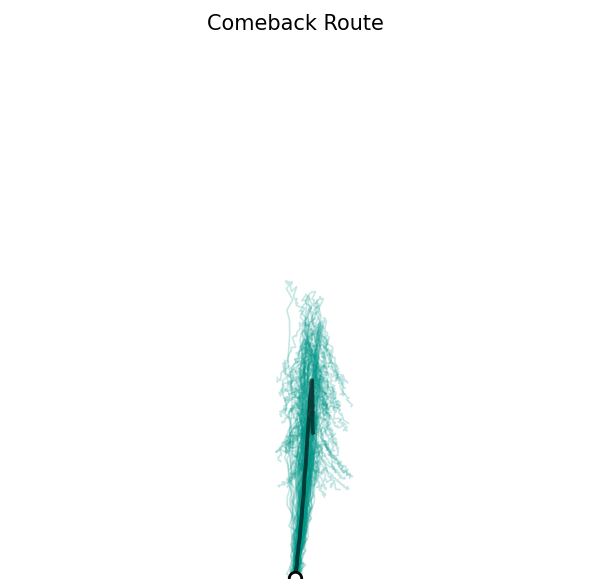

In [46]:
#Single route
fig = plot_synthetic_route_distribution('comeback', n_routes = 100, canonical_direction = 'right')
fig.show()

/var/folders/0x/5zm8wb3d25l1fz70vwm8jktc0000gn/T/ipykernel_21807/263249266.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


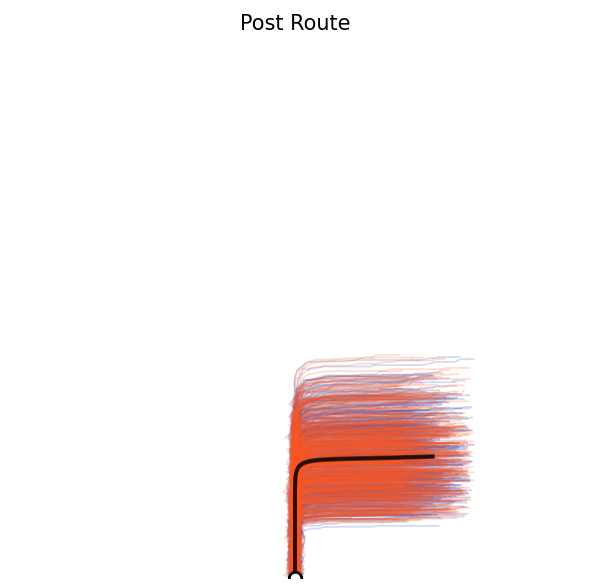

In [6]:
# multi route
route_names = ['dig', 'out']
fig = plot_synthetic_route_distribution(route_names)
fig.show()